## Evaluate ERA-Interim Cross validation


In [1]:
import os
import sys

import numpy as np
import pandas as pd
import xarray as xr
import colorcet as cc
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

base_dir = os.path.dirname(os.path.abspath('')).split(os.sep + 'eval_transferability')[0]

sys.path.append(os.path.sep.join([base_dir , 'src']))
from help_fcts import get_rmse, get_mae, get_mbe, get_r2, calc_anomaly

fig_dir = os.path.sep.join([base_dir, 'figures_transf', 'ERAI_stabilizedtraining'])
os.makedirs(fig_dir, exist_ok=True)

In [2]:
# load daily melt predictions
chunking = {'time': -1, 'y': -1, 'x': -1}
pred_dir = os.path.sep.join([base_dir, 'output', 'crossval_ERAI_modularNNEBM'])
pred_dir = os.path.sep.join([base_dir, 'output', 'crossval_CESM2_modularNNEBM_mse'])
pred_dir = os.path.sep.join([base_dir, 'output', 'crossval_ERAI_modularNNEBM_stabilized'])


# load climatology of true melt
#ds_clim = xr.open_dataset(os.path.sep.join([base_dir, 'data', 'interim', 'ERAI', 'HIRHAM5', 'firnpack', 'climat_snmel_1990-2013_smoothed15.nc']))
ds_clim = xr.open_dataset(os.path.sep.join([base_dir, 'data', 'interim', 'CESM2', 'HIRHAM5', 'firnpack', 'climat_1990-2013_smoothed15.nc']))
snmel_clim = ds_clim['snmel']#.sel(x=ds_pred['x'], y=ds_pred['y'])
snmel_clim


<xarray.DataArray 'snmel' (time: 366, y: 602, x: 402)> Size: 354MB
[88573464 values with dtype=float32]
Coordinates:
    lon      (y, x) float32 968kB ...
    lat      (y, x) float32 968kB ...
  * x        (x) float64 3kB 0.0 1.0 2.0 3.0 4.0 ... 398.0 399.0 400.0 401.0
  * y        (y) float64 5kB 0.0 1.0 2.0 3.0 4.0 ... 598.0 599.0 600.0 601.0
  * time     (time) datetime64[ns] 3kB 1980-01-01T12:00:00 ... 1980-12-31T12:...
Attributes:
    long_name:  Acc snow melt
    units:      mm/day weq
    height:     0.0
    time:       365.75

In [9]:
# def calc_anomaly(ds, clim):
#     md_clim = clim['time'].dt.strftime('%m-%d')        # DataArray of strings length 366
#     clim = clim.assign_coords(md=md_clim)              # attach md coordinate to the DataArray

#     # 2. group by the md coordinate and average (should give one value per md per spatial point)
#     clim = clim.groupby('md').mean(dim='time')   # dims: ('md', spatial...)

#     # 3. prepare the main data: build md for every day; map 02-29 -> 02-28 if desired
#     # da = ds_melt.set_index(z=['y', 'x']).unstack('z').transpose('time', 'y', 'x')

#     md_data = ds['time'].dt.strftime('%m-%d')
#     #md_data_fixed = md_data.where(md_data != '02-29', other='02-28')  # simple leap-day treatment
#     ds = ds.assign_coords(md=('time', md_data.values))         # attach md coord to data

#     # 4. subtract: groupby on md aligns with clim_by_md's md coordinate; broadcasting happens automatically
#     anomaly = (ds.groupby('md') - clim).compute()

#     return anomaly, clim, ds

In [10]:
# # predict anomalies for 2016 w.r.t. climatology 1990-2013

# ds_clim = ds_clim.sel(x=ds_pred['x'].astype(int), y=ds_pred['y'].astype(int))

# pred_da = ds_pred['snmel_pred'].sel(time=slice('1990-01-01','2016-12-31')).compute()
# true_da = ds_pred['snmel_true'].sel(time=slice('1990-01-01','2016-12-31')).compute()

# anomaly_pred, _, _ = calc_anomaly(pred_da, ds_clim['snmel'])
# anomaly_true, _, _ = calc_anomaly(true_da, ds_clim['snmel'])

## Basin-wise Scores of Modular NN

In [ ]:

years = range(2000, 2015, 2)
iter_n = range(5)
scaling_factor = 1.796553703424 / 58391 

metrics = ['total melt', 'RMSE', 'MAE', 'MBE', 'R2', 'R2_anomalies']

# Create multi-level index (years × categories)
index = pd.MultiIndex.from_product([years, iter_n], names=['year', 'iter'])

# Create DataFrame with this index and metric columns
df_per_year = pd.DataFrame(np.nan,  index=index, dtype=float, 
    columns=metrics)

for year in years:
    for it in iter_n:
        try:
            data_dir = os.path.sep.join([pred_dir, f'fold_{year}', f'iter_{it}', 'pred_data.zarr'])
            print(f'Load data {data_dir} ...')
            ds_pred = xr.open_dataset(data_dir).chunk(chunking)
            pred_da = ds_pred['snmel_pred'].compute()
            true_da = ds_pred['snmel_true'].compute()

            residual = pred_da - true_da
            total_melt = true_da.sum(dim=['time','x','y']).item()*scaling_factor
            df_per_year.loc[(year,it), 'total melt'] = total_melt
            df_per_year.loc[(year,it), 'RMSE'] = get_rmse(residual)
            df_per_year.loc[(year,it), 'MAE'] = get_mae(residual)
            df_per_year.loc[(year,it), 'MBE'] = get_mbe(residual)
            df_per_year.loc[(year,it), 'R2'] = get_r2(true_da.values, pred_da.values)

            #print('Calculate anomalies')
            anomaly_pred, _, _ = calc_anomaly(pred_da, ds_clim['snmel'].sel(x=ds_pred['x'].astype(int), y=ds_pred['y'].astype(int)))
            anomaly_true, _, _ = calc_anomaly(true_da, ds_clim['snmel'].sel(x=ds_pred['x'].astype(int), y=ds_pred['y'].astype(int)))
            df_per_year.loc[(year,it), 'R2_anomalies'] = get_r2(anomaly_true.values, anomaly_pred.values)
        except Exception as e:
            pass

display(df_per_year.round(2))

In [7]:
true_da

NameError: name 'true_da' is not defined

In [10]:
ds_pred

<xarray.Dataset> Size: 743MB
Dimensions:     (time: 730, y: 431, x: 295)
Coordinates:
  * x           (x) int32 1kB 51 52 53 54 55 56 57 ... 340 341 342 343 344 345
  * y           (y) int32 2kB 87 88 89 90 91 92 93 ... 512 513 514 515 516 517
  * time        (time) datetime64[ns] 6kB 1990-01-01T12:00:00 ... 1991-12-31T...
Data variables:
    snmel_true  (time, y, x) float32 371MB dask.array<chunksize=(730, 431, 295), meta=np.ndarray>
    snmel_pred  (time, y, x) float32 371MB dask.array<chunksize=(730, 431, 295), meta=np.ndarray>

In [11]:

valyears = [2012, 2014]#range(2000, 2015, 2)
appliedyears = [1990, 1991]
iter_n = [0,1]#range(5)
scaling_factor = 1.796553703424 / 58391 

metrics = ['total melt', 'RMSE', 'MAE', 'MBE', 'R2', 'R2_anomalies']

# Create multi-level index (years × categories)
index = pd.MultiIndex.from_product([valyears, iter_n, appliedyears], names=['valyear', 'iter', 'appliedyear'])

# Create DataFrame with this index and metric columns
df_per_year = pd.DataFrame(np.nan,  index=index, dtype=float, 
    columns=metrics)

for year in valyears:
    for it in iter_n:
        try:
            data_dir = os.path.sep.join([pred_dir, f'fold_{year}', f'iter_{it}', 'pred_data.zarr'])
            print(f'Load data {data_dir} ...')
            ds_pred = xr.open_dataset(data_dir).chunk(chunking)
            for ay in appliedyears:
                pred_da = ds_pred['snmel_pred'].sel(time=slice(f"{ay}-01-01", f"{ay}-12-31")).compute()
                true_da = ds_pred['snmel_true'].sel(time=slice(f"{ay}-01-01", f"{ay}-12-31")).compute()

                residual = pred_da - true_da
                total_melt = true_da.sum(dim=['time','x','y']).item()*scaling_factor
                df_per_year.loc[(year,it,ay), 'total melt'] = total_melt
                df_per_year.loc[(year,it,ay), 'RMSE'] = get_rmse(residual)
                df_per_year.loc[(year,it,ay), 'MAE'] = get_mae(residual)
                df_per_year.loc[(year,it,ay), 'MBE'] = get_mbe(residual)
                df_per_year.loc[(year,it,ay), 'R2'] = get_r2(true_da.values, pred_da.values)

                #print('Calculate anomalies')
                anomaly_pred, _, _ = calc_anomaly(pred_da, ds_clim['snmel'].sel(x=ds_pred['x'].astype(int), y=ds_pred['y'].astype(int)))
                anomaly_true, _, _ = calc_anomaly(true_da, ds_clim['snmel'].sel(x=ds_pred['x'].astype(int), y=ds_pred['y'].astype(int)))
                df_per_year.loc[(year,it,ay), 'R2_anomalies'] = get_r2(anomaly_true.values, anomaly_pred.values)
        except Exception as e:
            print(e)

display(df_per_year.round(2))

Load data /home/eschlager/MeltEmulation/output/crossval_ERAI_modularNNEBM_stabilized/fold_2012/iter_0/pred_data.zarr ...
Loaded data
Calculate for year 1990
                          total melt      RMSE       MAE       MBE        R2  \
valyear iter appliedyear                                                       
2012    0    1990         576.277791  0.854243  0.137204 -0.015431  0.961621   
             1991                NaN       NaN       NaN       NaN       NaN   
        1    1990                NaN       NaN       NaN       NaN       NaN   
             1991                NaN       NaN       NaN       NaN       NaN   
2014    0    1990                NaN       NaN       NaN       NaN       NaN   
             1991                NaN       NaN       NaN       NaN       NaN   
        1    1990                NaN       NaN       NaN       NaN       NaN   
             1991                NaN       NaN       NaN       NaN       NaN   

                          R2_anomalies  
v

total melt  RMSE   MAE   MBE    R2  R2_anomalies
valyear iter appliedyear                                                  
2012    0    1990             576.28  0.85  0.14 -0.02  0.96          0.89
             1991             547.18  0.81  0.13 -0.00  0.96          0.90
        1    1990             576.28  0.85  0.13 -0.04  0.96          0.90
             1991             547.18  0.83  0.13 -0.02  0.96          0.90
2014    0    1990             576.28  0.86  0.16  0.01  0.96          0.89
             1991             547.18  0.81  0.16  0.02  0.96          0.90
        1    1990             576.28  0.86  0.26  0.12  0.96          0.89
             1991             547.18  0.84  0.26  0.13  0.96          0.90

## Scores aggregations

In [ ]:
# models evaluated on the separate year; variance shows only the effect of the random seed
stats = df_per_year.groupby(level=['valyear','appliedyear']).agg(['mean', 'std'])
display(stats.round(2))

total melt       RMSE         MAE         MBE          R2  \
                          mean  std  mean   std  mean   std  mean   std  mean   
valyear appliedyear                                                             
2012    1990            576.28  0.0  0.85  0.00  0.14  0.00 -0.03  0.01  0.96   
        1991            547.18  0.0  0.82  0.01  0.13  0.00 -0.01  0.01  0.96   
2014    1990            576.28  0.0  0.86  0.00  0.21  0.07  0.07  0.08  0.96   
        1991            547.18  0.0  0.83  0.02  0.21  0.07  0.08  0.08  0.96   

                         R2_anomalies       
                     std         mean  std  
valyear appliedyear                         
2012    1990         0.0         0.89  0.0  
        1991         0.0         0.90  0.0  
2014    1990         0.0         0.89  0.0  
        1991         0.0         0.90  0.0

In [19]:
# models evaluated across all the years together; variance shows how the performance metric depends on the year that we test on; i.e. sensitivity of the 
# testing itself w.r.t. climate state
stats = df_per_year.groupby(level=['valyear', 'iter']).agg(['mean', 'std'])
display(stats.round(2))

total melt         RMSE         MAE         MBE          R2       \
                   mean    std  mean   std  mean   std  mean   std  mean  std   
valyear iter                                                                    
2012    0        561.73  20.57  0.83  0.03  0.13  0.00 -0.01  0.01  0.96  0.0   
        1        561.73  20.57  0.84  0.01  0.13  0.00 -0.03  0.01  0.96  0.0   
2014    0        561.73  20.57  0.84  0.03  0.16  0.01  0.01  0.01  0.96  0.0   
        1        561.73  20.57  0.85  0.01  0.26  0.00  0.13  0.01  0.96  0.0   

             R2_anomalies        
                     mean   std  
valyear iter                     
2012    0             0.9  0.01  
        1             0.9  0.00  
2014    0             0.9  0.01  
        1             0.9  0.00

In [20]:
# each year modeled by all the models; variance shows the difference of the model performances per year; i.e. sensitivity w.r.t. training data (and seed)
stats = df_per_year.groupby(level=['appliedyear']).agg(['mean', 'std'])
display(stats.round(2))

total melt       RMSE         MAE         MBE          R2       \
                  mean  std  mean   std  mean   std  mean   std  mean  std   
appliedyear                                                                  
1990            576.28  0.0  0.85  0.01  0.17  0.06  0.02  0.07  0.96  0.0   
1991            547.18  0.0  0.82  0.01  0.17  0.06  0.03  0.07  0.96  0.0   

            R2_anomalies       
                    mean  std  
appliedyear                    
1990                0.89  0.0  
1991                0.90  0.0

In [7]:
stats_all = df_per_year.agg(['mean', 'std'])
stats_all

,total melt,RMSE,MAE,MBE,R2,R2_anomalies
mean,710.435231,0.866614,0.185060,0.051021,0.967417,0.903327
std,154.547349,0.055655,0.037208,0.043484,0.005202,0.017282


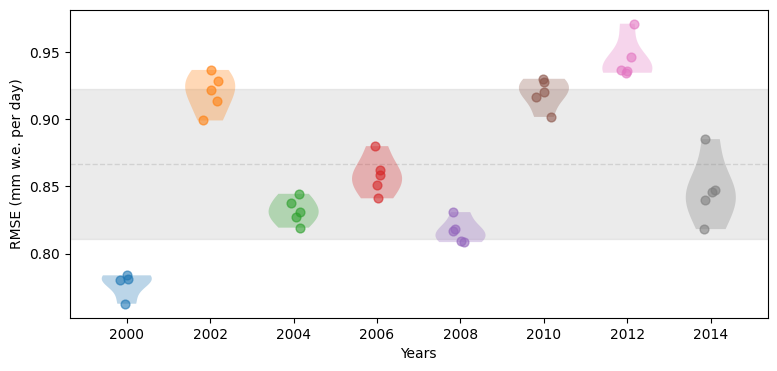

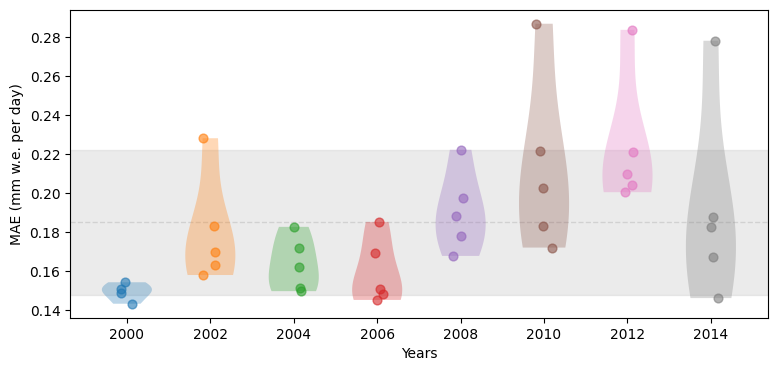

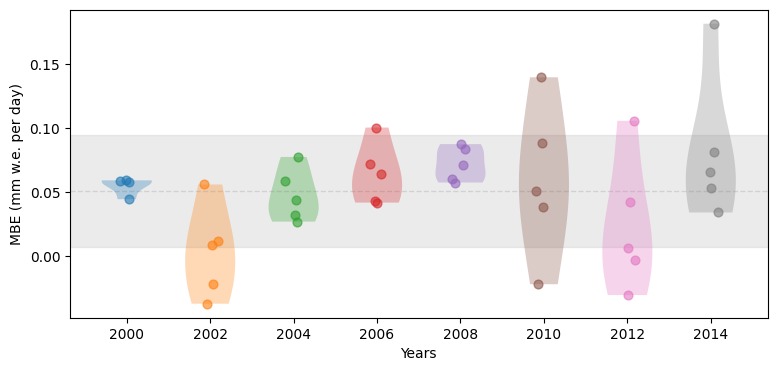

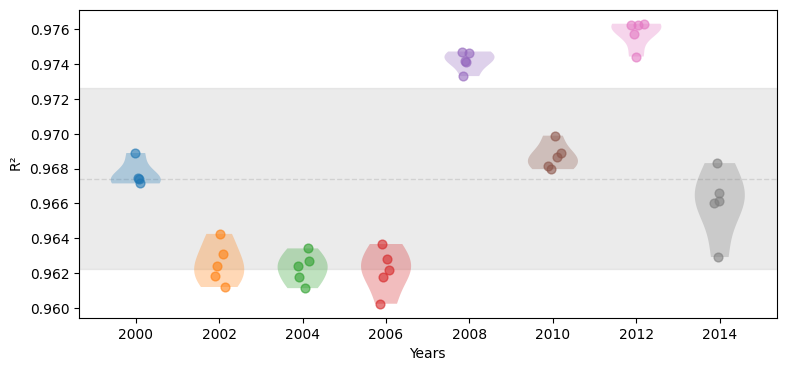

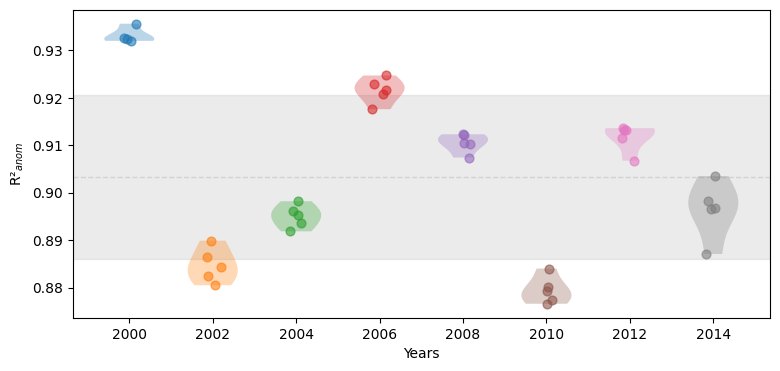

In [9]:
import seaborn as sns
cmap = mcolors.ListedColormap(cc.glasbey_category10)
colors = cmap.colors

for metric_to_plot in ['RMSE', 'MAE', 'MBE', 'R2', 'R2_anomalies']:
    fig, ax = plt.subplots(figsize=(9,4))
    ax.axhline(y=stats_all[metric_to_plot]['mean'], color='silver', alpha=0.6, linestyle='--', linewidth=1, zorder=-5)
    ax.axhspan(ymin=stats_all[metric_to_plot]['mean']-stats_all[metric_to_plot]['std'], ymax=stats_all[metric_to_plot]['mean']+stats_all[metric_to_plot]['std'], 
               color='silver', alpha=0.3)
    for i,bb in enumerate(years):
        dff = df_per_year.xs(bb, level='year')[metric_to_plot]
        dff_train = dff.loc[:2014].dropna()
        #ax.boxplot(dff_train.values, positions=[i], widths=0.6)
        #vp = ax.violinplot(data=dff_train, inner="point", density_norm="count")
        vp = ax.violinplot(dff_train.values, positions=[i], widths=0.6, showmedians=False, showextrema=False)
        for pc in vp['bodies']:
            pc.set_facecolor(colors[i])
            pc.set_alpha(0.3)  # 0.5 = 50% transparent
        plt.scatter((np.random.rand(len(dff_train)))*0.2+i-0.1, dff_train.values, s=40, color=colors[i], linewidth=None, alpha=0.6)
        
        # plt.scatter(i-0.1, dff[2015], marker='D', color=colors[i], edgecolor='k', s=35, linewidth=.5, label='2015')
        # plt.scatter(i+0.1, dff[2014], marker='X', color=colors[i], edgecolor='k', s=50, linewidth=.5, label='2014')
        # plt.scatter(i, dff[2016], marker='*', color='k', edgecolor='k', s=70, linewidth=.5, label='2016')

        ax.set_xticks(np.arange(len(years)))
        ax.set_xticklabels(years)


        ax.set_xticks(np.arange(len(years)))
        ax.set_xticklabels(years)
        if metric_to_plot=='R2':
            ax.set_ylabel('R$²$')
        elif metric_to_plot=='R2_anomalies':
            ax.set_ylabel('R$²_{anom}$')
        else:
            ax.set_ylabel(metric_to_plot+' (mm w.e. per day)')
        ax.set_xlabel('Years')
        fig.savefig(os.path.sep.join([fig_dir, f"crossval_violinplot{metric_to_plot}.png"]), bbox_inches='tight', dpi=200)

    plt.show()

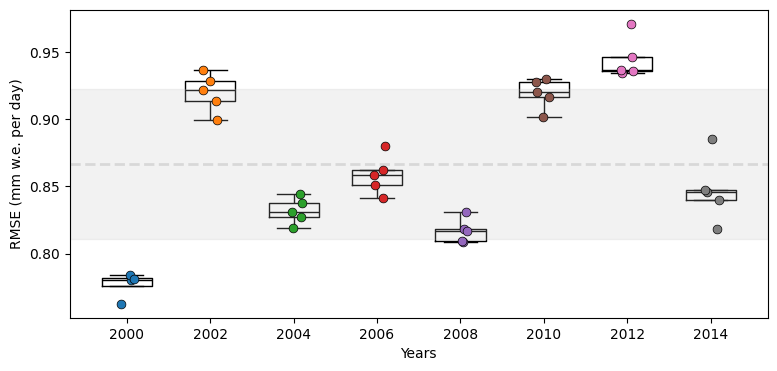

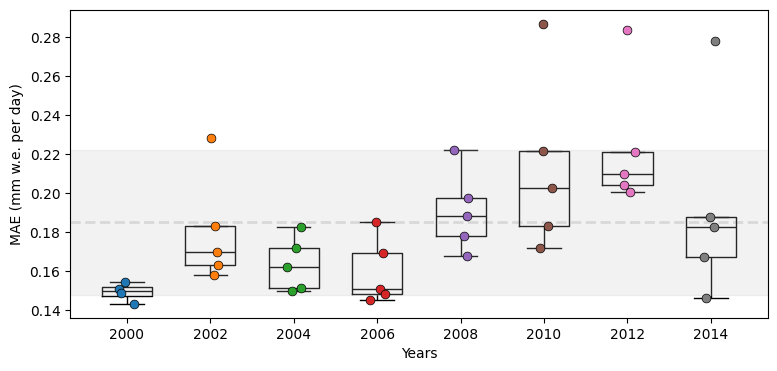

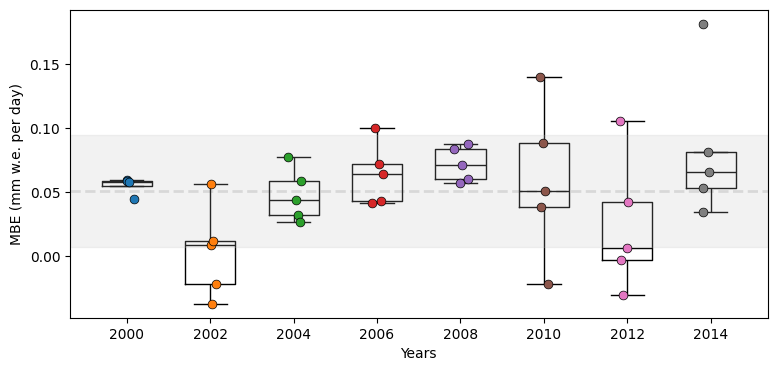

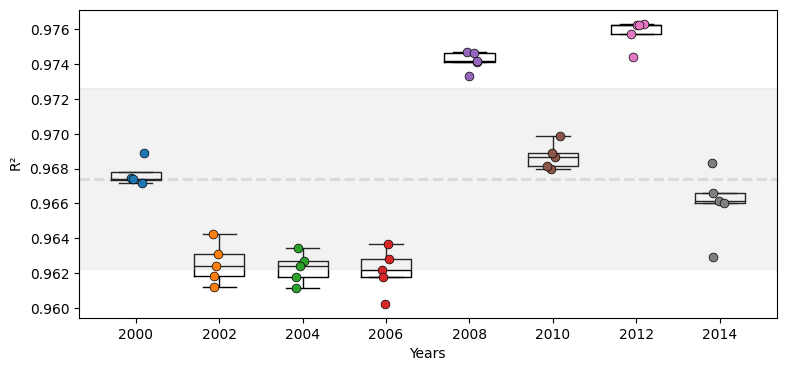

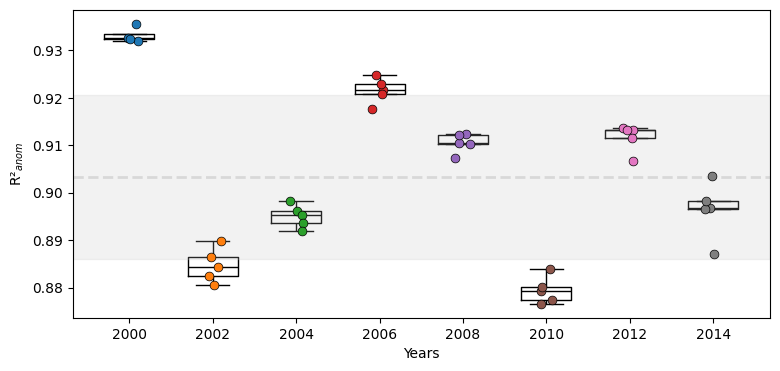

In [10]:
import seaborn as sns
cmap = mcolors.ListedColormap(cc.glasbey_category10)
colors = cmap.colors

for metric_to_plot in ['RMSE', 'MAE', 'MBE', 'R2', 'R2_anomalies']:
    fig, ax = plt.subplots(figsize=(9,4))
    ax.axhline(y=stats_all[metric_to_plot]['mean'], color='silver', alpha=0.5, linestyle='--', linewidth=2, zorder=-5)
    ax.axhspan(ymin=stats_all[metric_to_plot]['mean']-stats_all[metric_to_plot]['std'], ymax=stats_all[metric_to_plot]['mean']+stats_all[metric_to_plot]['std'], 
               color='silver', alpha=0.2)
    for i,bb in enumerate(years):
        dff = df_per_year.xs(bb, level='year')[metric_to_plot]
        dff_train = dff.loc[:2014].dropna()
        #ax.boxplot(dff_train.values, positions=[i], widths=0.6)
        #vp = ax.violinplot(data=dff_train, inner="point", density_norm="count")
        vp = sns.boxplot(dff_train.values, positions=[i], showfliers=False, widths=0.6, fill=False, color='k', linewidth=1, ax=ax, zorder=-1)
        
        ax.scatter((np.random.rand(len(dff_train)))*0.2+i-0.1, dff_train.values, s=40, color=colors[i], linewidth=0.5, edgecolors='k', alpha=1., zorder=1)
        
        # plt.scatter(i-0.1, dff[2015], marker='D', color=colors[i], edgecolor='k', s=35, linewidth=.5, label='2015')
        # plt.scatter(i+0.1, dff[2014], marker='X', color=colors[i], edgecolor='k', s=50, linewidth=.5, label='2014')
        # plt.scatter(i, dff[2016], marker='*', color='k', edgecolor='k', s=70, linewidth=.5, label='2016')

        ax.set_xticks(np.arange(len(years)))
        ax.set_xticklabels(years)


        ax.set_xticks(np.arange(len(years)))
        ax.set_xticklabels(years)
        if metric_to_plot=='R2':
            ax.set_ylabel('R$²$')
        elif metric_to_plot=='R2_anomalies':
            ax.set_ylabel('R$²_{anom}$')
        else:
            ax.set_ylabel(metric_to_plot+' (mm w.e. per day)')
        ax.set_xlabel('Years')
        fig.savefig(os.path.sep.join([fig_dir, f"crossval_boxplot{metric_to_plot}.png"]), bbox_inches='tight', dpi=200)

    plt.show()

In [60]:
# from matplotlib.lines import Line2D
# import matplotlib.pyplot as plt

# legend_elements = [
#     Line2D([0], [0], marker='o', color='w', markerfacecolor='grey', 
#             markersize=8, label='1990-2013'),
#     Line2D([0], [0], marker='X', color='w', markerfacecolor='grey', 
#             markeredgecolor='k', markersize=7, label='2014'),
#     Line2D([0], [0], marker='D', color='w', markerfacecolor='grey', 
#             markeredgecolor='k', markersize=6, label='2015'),
#     Line2D([0], [0], marker='*', color='w', markerfacecolor='k', 
#             markeredgecolor='k', markersize=8, label='2016'),
# ]

# # Create a separate figure for the legend only
# fig_legend = plt.figure(figsize=(8, 1))
# ax_legend = fig_legend.add_subplot(111)
# ax_legend.axis('off')  # Hide the axes

# legend = ax_legend.legend(handles=legend_elements, ncols=4, loc='center', 
#                           frameon=True, fontsize=12)

# fig_legend.savefig(os.path.sep.join([fig_dir, f"modularNN_EBM_violinplot_legend.png"]), bbox_inches='tight', dpi=200)

In [17]:
import os
pred_dir = os.path.sep.join([base_dir, 'output', 'crossval_CESM2_modularNNEBM_mse'])
data_dir = os.path.sep.join([pred_dir, f'fold_2016', f'iter_0', 'pred_val.zarr'])
print(f'Load data {data_dir} ...')
chunking = {'time': -1, 'y': -1, 'x': -1}
ds_pred = xr.open_dataset(data_dir).chunk(chunking)#.sel(time=slice('2016-01-01','2016-12-31'))
pred_da = ds_pred['snmel_pred'].compute()
true_da = ds_pred['snmel_true'].compute()



Load data /home/eschlager/MeltEmulation/output/crossval_CESM2_modularNNEBM_mse/fold_2016/iter_0/pred_val.zarr ...


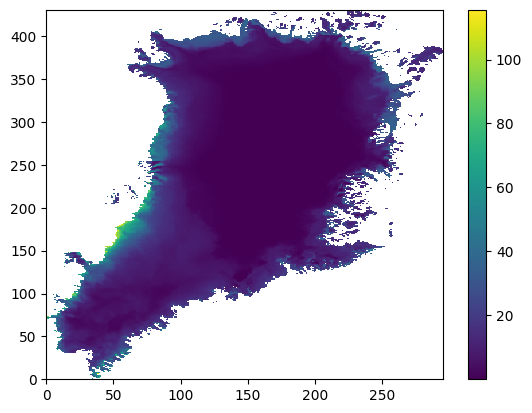

In [22]:
plt.pcolormesh(pred_da.isel(time=180))
plt.colorbar()

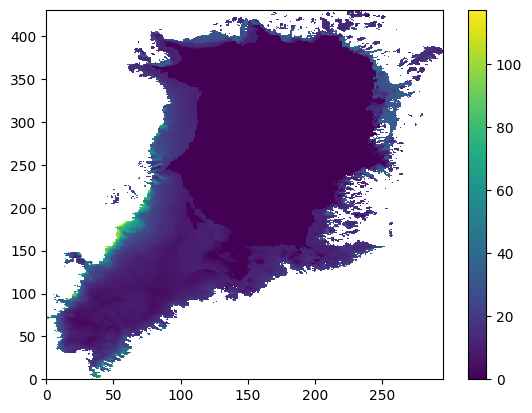

In [23]:
plt.pcolormesh(true_da.isel(time=180))
plt.colorbar()

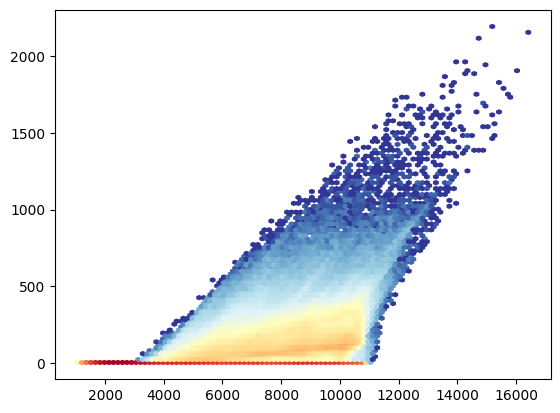

In [16]:
plt.hexbin(pred_da.values.flatten(), true_da.values.flatten(), bins='log', cmap='RdYlBu_r')